In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_column',None)

In [2]:
# 1. Load JSON

with open(r"D:\VS Code\Health_Data_Fraud_Risk_Analysis\data\health_data_100k.json", "r", encoding="utf-8") as f:
    data = json.load(f)


df = pd.DataFrame(data)

In [3]:
df.shape

(100000, 49)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 49 columns):
 #   Column                                                             Non-Null Count   Dtype  
---  ------                                                             --------------   -----  
 0   provider_id                                                        10882 non-null   object 
 1   agency_name                                                        100000 non-null  object 
 2   street_address                                                     10882 non-null   object 
 3   city                                                               100000 non-null  object 
 4   state                                                              100000 non-null  object 
 5   zip_code                                                           10882 non-null   object 
 6   total_episodes_non_lupa                                            100000 non-null  int64  
 7   distinct_ben

In [5]:
df.head()

,provider_id,agency_name,street_address,city,state,zip_code,total_episodes_non_lupa,distinct_beneficiaries_non_lupa,average_number_of_total_visits_per_episode_non_lupa,average_number_of_skilled_nursing_visits_per_episode_non_lupa,average_number_of_pt_visits_per_episode_non_lupa,average_number_of_ot_visits_per_episode_non_lupa,average_number_of_st_visits_per_episode_non_lupa,average_number_of_home_health_aide_visits_per_episode_non_lupa,average_number_of_medical_social_visits_per_episode_non_lupa,total_hha_charge_amount_non_lupa,total_hha_medicare_payment_amount_non_lupa,total_hha_medicare_standard_payment_amount_non_lupa,outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa,total_lupa_episodes,total_hha_medicare_payment_amount_for_lupas,average_age,male_beneficiaries,female_beneficiaries,nondual_beneficiaries,dua_beneficiaries,white_beneficiaries,black_beneficiaries,asian_pacific_islander_beneficiaries,hispanic_beneficiaries,american_indian_or_alaska_native_beneficiaries,other_unknown_beneficiaries,average_hcc_score,percent_of_beneficiaries_with_atrial_fibrillation,percent_of_beneficiaries_with_alzheimers,percent_of_beneficiaries_with_asthma,percent_of_beneficiaries_with_cancer,percent_of_beneficiaries_with_chf,percent_of_beneficiaries_with_chronic_kidney_disease,percent_of_beneficiaries_with_copd,percent_of_beneficiaries_with_depression,percent_of_beneficiaries_with_diabetes,percent_of_beneficiaries_with_hyperlipidemia,percent_of_beneficiaries_with_hypertension,percent_of_beneficiaries_with_ihd,percent_of_beneficiaries_with_osteoporosis,percent_of_beneficiaries_with_ra_oa,percent_of_beneficiaries_with_schizophrenia,percent_of_beneficiaries_with_stroke
0,58330,"DIVINE HOME HEALTH, INC",14625 CARMENITA ROAD SUITE 228,NORWALK,CA,90650,681,486,13.4,9.8,2.7,0.1,0.0,0.8,0.0,1368276,2217148,1787361,6.5,31.0,12912.0,80,139.0,347.0,55.0,431.0,35.0,NaN,407.0,26.0,NaN,17.0,2.00,9,39.0,15.0,8,30.0,39.0,16.0,21.0,74.0,70.0,NaN,57.0,44,72.0,4.0,8
1,58376,"ORANGE COUNTY CARE PROVIDERS, INC",14700 E FIRESTONE BLVD SUITE 128,LA MIRADA,CA,90638,614,293,18.0,12.8,4.3,0.1,0.1,0.7,0.0,1652285,2137998,1747600,6.2,44.0,16321.0,82,97.0,196.0,92.0,201.0,189.0,NaN,63.0,NaN,NaN,28.0,2.74,24,46.0,19.0,16,45.0,51.0,37.0,49.0,49.0,72.0,NaN,54.0,19,67.0,7.0,12
2,147844,"ALERT HOME HEALTH CARE, INC","8118 N MILWAUKEE AVENUE, STE 109",NILES,IL,60714,501,197,10.4,7.5,1.5,0.1,0.0,1.3,0.0,669226,1189842,1165889,0.0,43.0,11642.0,79,58.0,139.0,81.0,116.0,149.0,NaN,17.0,NaN,NaN,13.0,2.16,23,27.0,20.0,9,52.0,32.0,28.0,39.0,68.0,73.0,NaN,68.0,23,NaN,3.0,10
3,227290,"SUBURBAN HOME HEALTH CARE, INC",1050 COMMONWEALTH AVE,BOSTON,MA,2115,1466,696,31.9,17.2,4.6,0.5,0.2,9.5,0.0,5856605,5549658,4418284,8.8,58.0,23848.0,82,203.0,493.0,117.0,579.0,476.0,31.0,108.0,NaN,NaN,71.0,2.25,28,33.0,14.0,14,48.0,49.0,16.0,40.0,54.0,64.0,NaN,63.0,16,62.0,10.0,7
4,747139,KOREAN HOME HEALTH,1908 ROYAL LANE SUITE 100,DALLAS,TX,75229,1691,419,15.0,8.3,1.8,0.1,0.0,4.7,0.0,3811831,3725304,3914596,0.0,24.0,8595.0,78,146.0,273.0,75.0,344.0,NaN,NaN,384.0,NaN,NaN,17.0,1.50,6,31.0,12.0,4,28.0,31.0,16.0,16.0,53.0,NaN,NaN,33.0,35,74.0,2.0,6


In [6]:
df.isnull().sum()

provider_id                                                          89118
agency_name                                                              0
street_address                                                       89118
city                                                                     0
state                                                                    0
zip_code                                                             89118
total_episodes_non_lupa                                                  0
distinct_beneficiaries_non_lupa                                          0
average_number_of_total_visits_per_episode_non_lupa                      0
average_number_of_skilled_nursing_visits_per_episode_non_lupa            0
average_number_of_pt_visits_per_episode_non_lupa                         0
average_number_of_ot_visits_per_episode_non_lupa                         0
average_number_of_st_visits_per_episode_non_lupa                         0
average_number_of_home_he

In [7]:
# -----------------------------------------
# STEP 1: Automatic datatype detection
# -----------------------------------------

for col in df.columns:

    numeric = pd.to_numeric(df[col], errors="coerce")

    valid_ratio = (
        numeric.notna().sum()
        / df[col].notna().sum()
    )

    if valid_ratio >= 0.90:
        df[col] = numeric

# -----------------------------------------
# STEP 3: Check datatypes after automatic conversion
# -----------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 49 columns):
 #   Column                                                             Non-Null Count   Dtype  
---  ------                                                             --------------   -----  
 0   provider_id                                                        10882 non-null   float64
 1   agency_name                                                        100000 non-null  object 
 2   street_address                                                     10882 non-null   object 
 3   city                                                               100000 non-null  object 
 4   state                                                              100000 non-null  object 
 5   zip_code                                                           10882 non-null   float64
 6   total_episodes_non_lupa                                            100000 non-null  int64  
 7   distinct_ben

In [8]:
# -----------------------------------------
# STEP 2: Convert to suitable Pandas dtypes
# -----------------------------------------

df = df.convert_dtypes()


# -----------------------------------------
# STEP 3: Check datatypes after automatic conversion
# -----------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 49 columns):
 #   Column                                                             Non-Null Count   Dtype  
---  ------                                                             --------------   -----  
 0   provider_id                                                        10882 non-null   Int64  
 1   agency_name                                                        100000 non-null  string 
 2   street_address                                                     10882 non-null   string 
 3   city                                                               100000 non-null  string 
 4   state                                                              100000 non-null  string 
 5   zip_code                                                           10882 non-null   Int64  
 6   total_episodes_non_lupa                                            100000 non-null  Int64  
 7   distinct_ben

In [9]:

# -----------------------------------------
# STEP 4: Manual correction for special columns
# -----------------------------------------

df["provider_id"] = df["provider_id"].astype("string")

df["zip_code"] = df["zip_code"].astype("string")


# -----------------------------------------
# STEP 5: Final datatype check
# -----------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 49 columns):
 #   Column                                                             Non-Null Count   Dtype  
---  ------                                                             --------------   -----  
 0   provider_id                                                        10882 non-null   string 
 1   agency_name                                                        100000 non-null  string 
 2   street_address                                                     10882 non-null   string 
 3   city                                                               100000 non-null  string 
 4   state                                                              100000 non-null  string 
 5   zip_code                                                           10882 non-null   string 
 6   total_episodes_non_lupa                                            100000 non-null  Int64  
 7   distinct_ben

In [10]:
df.head()

,provider_id,agency_name,street_address,city,state,zip_code,total_episodes_non_lupa,distinct_beneficiaries_non_lupa,average_number_of_total_visits_per_episode_non_lupa,average_number_of_skilled_nursing_visits_per_episode_non_lupa,average_number_of_pt_visits_per_episode_non_lupa,average_number_of_ot_visits_per_episode_non_lupa,average_number_of_st_visits_per_episode_non_lupa,average_number_of_home_health_aide_visits_per_episode_non_lupa,average_number_of_medical_social_visits_per_episode_non_lupa,total_hha_charge_amount_non_lupa,total_hha_medicare_payment_amount_non_lupa,total_hha_medicare_standard_payment_amount_non_lupa,outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa,total_lupa_episodes,total_hha_medicare_payment_amount_for_lupas,average_age,male_beneficiaries,female_beneficiaries,nondual_beneficiaries,dua_beneficiaries,white_beneficiaries,black_beneficiaries,asian_pacific_islander_beneficiaries,hispanic_beneficiaries,american_indian_or_alaska_native_beneficiaries,other_unknown_beneficiaries,average_hcc_score,percent_of_beneficiaries_with_atrial_fibrillation,percent_of_beneficiaries_with_alzheimers,percent_of_beneficiaries_with_asthma,percent_of_beneficiaries_with_cancer,percent_of_beneficiaries_with_chf,percent_of_beneficiaries_with_chronic_kidney_disease,percent_of_beneficiaries_with_copd,percent_of_beneficiaries_with_depression,percent_of_beneficiaries_with_diabetes,percent_of_beneficiaries_with_hyperlipidemia,percent_of_beneficiaries_with_hypertension,percent_of_beneficiaries_with_ihd,percent_of_beneficiaries_with_osteoporosis,percent_of_beneficiaries_with_ra_oa,percent_of_beneficiaries_with_schizophrenia,percent_of_beneficiaries_with_stroke
0,58330,"DIVINE HOME HEALTH, INC",14625 CARMENITA ROAD SUITE 228,NORWALK,CA,90650,681,486,13.4,9.8,2.7,0.1,0.0,0.8,0.0,1368276,2217148,1787361,6.5,31,12912,80,139,347,55,431,35,<NA>,407,26,<NA>,17,2.0,9,39,15,8,30,39,16,21,74,70,<NA>,57,44,72,4,8
1,58376,"ORANGE COUNTY CARE PROVIDERS, INC",14700 E FIRESTONE BLVD SUITE 128,LA MIRADA,CA,90638,614,293,18.0,12.8,4.3,0.1,0.1,0.7,0.0,1652285,2137998,1747600,6.2,44,16321,82,97,196,92,201,189,<NA>,63,<NA>,<NA>,28,2.74,24,46,19,16,45,51,37,49,49,72,<NA>,54,19,67,7,12
2,147844,"ALERT HOME HEALTH CARE, INC","8118 N MILWAUKEE AVENUE, STE 109",NILES,IL,60714,501,197,10.4,7.5,1.5,0.1,0.0,1.3,0.0,669226,1189842,1165889,0.0,43,11642,79,58,139,81,116,149,<NA>,17,<NA>,<NA>,13,2.16,23,27,20,9,52,32,28,39,68,73,<NA>,68,23,<NA>,3,10
3,227290,"SUBURBAN HOME HEALTH CARE, INC",1050 COMMONWEALTH AVE,BOSTON,MA,2115,1466,696,31.9,17.2,4.6,0.5,0.2,9.5,0.0,5856605,5549658,4418284,8.8,58,23848,82,203,493,117,579,476,31,108,<NA>,<NA>,71,2.25,28,33,14,14,48,49,16,40,54,64,<NA>,63,16,62,10,7
4,747139,KOREAN HOME HEALTH,1908 ROYAL LANE SUITE 100,DALLAS,TX,75229,1691,419,15.0,8.3,1.8,0.1,0.0,4.7,0.0,3811831,3725304,3914596,0.0,24,8595,78,146,273,75,344,<NA>,<NA>,384,<NA>,<NA>,17,1.5,6,31,12,4,28,31,16,16,53,<NA>,<NA>,33,35,74,2,6


In [11]:
df.isnull().sum()

provider_id                                                          89118
agency_name                                                              0
street_address                                                       89118
city                                                                     0
state                                                                    0
zip_code                                                             89118
total_episodes_non_lupa                                                  0
distinct_beneficiaries_non_lupa                                          0
average_number_of_total_visits_per_episode_non_lupa                      0
average_number_of_skilled_nursing_visits_per_episode_non_lupa            0
average_number_of_pt_visits_per_episode_non_lupa                         0
average_number_of_ot_visits_per_episode_non_lupa                         0
average_number_of_st_visits_per_episode_non_lupa                         0
average_number_of_home_he

In [12]:
for col in df.columns:

    # Numeric column
    if pd.api.types.is_numeric_dtype(df[col]):

        # Convert numeric column to float
        df[col] = df[col].astype("float64")

        mean = df[col].mean()
        median = df[col].median()

        if mean != 0:

            difference = abs(mean - median) / abs(mean) * 100

            if difference > 10:
                df[col] = df[col].fillna(median)
            else:
                df[col] = df[col].fillna(mean)

        else:
            df[col] = df[col].fillna(median)

    # Object / String column
    else:

        mode = df[col].mode()

        if not mode.empty:
            df[col] = df[col].fillna(mode[0])

In [13]:
df.isnull().sum()

provider_id                                                          0
agency_name                                                          0
street_address                                                       0
city                                                                 0
state                                                                0
zip_code                                                             0
total_episodes_non_lupa                                              0
distinct_beneficiaries_non_lupa                                      0
average_number_of_total_visits_per_episode_non_lupa                  0
average_number_of_skilled_nursing_visits_per_episode_non_lupa        0
average_number_of_pt_visits_per_episode_non_lupa                     0
average_number_of_ot_visits_per_episode_non_lupa                     0
average_number_of_st_visits_per_episode_non_lupa                     0
average_number_of_home_health_aide_visits_per_episode_non_lupa       0
averag

In [14]:
for col in df.select_dtypes(include="number").columns:

    # --------------------------------
    # 1. Describe statistics
    # --------------------------------
    description = df[col].describe()

    # --------------------------------
    # 2. IQR calculation
    # --------------------------------
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # --------------------------------
    # 3. Find outliers
    # --------------------------------
    outlier_values = df.loc[
        (df[col] < lower_limit) |
        (df[col] > upper_limit),
        col
    ].dropna().tolist()

    # --------------------------------
    # 4. Output
    # --------------------------------

    print("=" * 70)

    print("COLUMN:", col)

    print("\nDESCRIBE:")
    print(description)

    print("\nOUTLIER COUNT:", len(outlier_values))

    print("\nOUTLIER LIST:")
    print(outlier_values)

    print("=" * 70)
    print()

COLUMN: total_episodes_non_lupa

DESCRIBE:
count    100000.000000
mean        552.251390
std         654.651974
min          11.000000
25%         133.000000
50%         343.000000
75%         744.000000
max       49987.000000
Name: total_episodes_non_lupa, dtype: float64

OUTLIER COUNT: 5940

OUTLIER LIST:
[1691.0, 2106.0, 4029.0, 2205.0, 2105.0, 2457.0, 7127.0, 2416.0, 2401.0, 3083.0, 3232.0, 1846.0, 4464.0, 3062.0, 2102.0, 1742.0, 1901.0, 3880.0, 2327.0, 1971.0, 2145.0, 3458.0, 2746.0, 3505.0, 2074.0, 1830.0, 2431.0, 8329.0, 1855.0, 4344.0, 3588.0, 2367.0, 3630.0, 7279.0, 11564.0, 4499.0, 8223.0, 4809.0, 2176.0, 7093.0, 1962.0, 1907.0, 1728.0, 2075.0, 2813.0, 2323.0, 4385.0, 4521.0, 6414.0, 6784.0, 1929.0, 3014.0, 6754.0, 1936.0, 2139.0, 1827.0, 3754.0, 2334.0, 1765.0, 3311.0, 3565.0, 3028.0, 1816.0, 5097.0, 1778.0, 1798.0, 3133.0, 2306.0, 1995.0, 3287.0, 3417.0, 1965.0, 1699.0, 6679.0, 6623.0, 6948.0, 1950.0, 3427.0, 1870.0, 1814.0, 2247.0, 2365.0, 1959.0, 1844.0, 2744.0, 2197.0, 4

In [15]:
# Feature engineering

df['average_age'].unique()

array([80., 82., 79., 78., 71., 74., 75., 76., 77., 81., 72., 63., 69.,
       73., 83., 67., 84., 64., 68., 66., 70., 85., 65., 87., 86., 56.,
       60., 88., 61., 62., 58., 59., 89., 57., 54., 90., 52., 91., 53.])

In [16]:
# Average age
# < 70
# Low
# 70–80
# Medium
# > 80
# High
# Higher average age segment

def age(data):
    if data<70:
        return 'Below 70'
    elif data >= 70 and data < 80:
        return '70 to 80'
    else:
        return 'Above 80'

In [17]:
df['average_age_segment'] = df['average_age'].apply(age)

In [18]:
# average_number_of_total_visits_per_episode_non_lupa 
# to
# Average total visits/episode
# < 12
# Low
# 12–20
# Medium
# > 20
# High
# Lower / moderate / higher service intensity

def visit(data):
    if data < 12:
        return 'Low'
    elif data >= 12 and data <= 20:
        return 'Medium'
    else:
        return 'High'

df["average_total_visit_per_episode"] = df['average_number_of_total_visits_per_episode_non_lupa'].apply(visit)

In [19]:
df.head(3)

,provider_id,agency_name,street_address,city,state,zip_code,total_episodes_non_lupa,distinct_beneficiaries_non_lupa,average_number_of_total_visits_per_episode_non_lupa,average_number_of_skilled_nursing_visits_per_episode_non_lupa,average_number_of_pt_visits_per_episode_non_lupa,average_number_of_ot_visits_per_episode_non_lupa,average_number_of_st_visits_per_episode_non_lupa,average_number_of_home_health_aide_visits_per_episode_non_lupa,average_number_of_medical_social_visits_per_episode_non_lupa,total_hha_charge_amount_non_lupa,total_hha_medicare_payment_amount_non_lupa,total_hha_medicare_standard_payment_amount_non_lupa,outlier_payments_as_a_percent_of_medicare_payment_amount_non_lupa,total_lupa_episodes,total_hha_medicare_payment_amount_for_lupas,average_age,male_beneficiaries,female_beneficiaries,nondual_beneficiaries,dua_beneficiaries,white_beneficiaries,black_beneficiaries,asian_pacific_islander_beneficiaries,hispanic_beneficiaries,american_indian_or_alaska_native_beneficiaries,other_unknown_beneficiaries,average_hcc_score,percent_of_beneficiaries_with_atrial_fibrillation,percent_of_beneficiaries_with_alzheimers,percent_of_beneficiaries_with_asthma,percent_of_beneficiaries_with_cancer,percent_of_beneficiaries_with_chf,percent_of_beneficiaries_with_chronic_kidney_disease,percent_of_beneficiaries_with_copd,percent_of_beneficiaries_with_depression,percent_of_beneficiaries_with_diabetes,percent_of_beneficiaries_with_hyperlipidemia,percent_of_beneficiaries_with_hypertension,percent_of_beneficiaries_with_ihd,percent_of_beneficiaries_with_osteoporosis,percent_of_beneficiaries_with_ra_oa,percent_of_beneficiaries_with_schizophrenia,percent_of_beneficiaries_with_stroke,average_age_segment,average_total_visit_per_episode
0,58330,"DIVINE HOME HEALTH, INC",14625 CARMENITA ROAD SUITE 228,NORWALK,CA,90650,681.0,486.0,13.4,9.8,2.7,0.1,0.0,0.8,0.0,1368276.0,2217148.0,1787361.0,6.5,31.0,12912.0,80.0,139.0,347.0,55.0,431.0,35.0,25.0,407.0,26.0,2.0,17.0,2.00,9.0,39.0,15.0,8.0,30.0,39.0,16.0,21.0,74.0,70.0,70.176492,57.0,44.0,72.000000,4.0,8.0,Above 80,Medium
1,58376,"ORANGE COUNTY CARE PROVIDERS, INC",14700 E FIRESTONE BLVD SUITE 128,LA MIRADA,CA,90638,614.0,293.0,18.0,12.8,4.3,0.1,0.1,0.7,0.0,1652285.0,2137998.0,1747600.0,6.2,44.0,16321.0,82.0,97.0,196.0,92.0,201.0,189.0,25.0,63.0,6.0,2.0,28.0,2.74,24.0,46.0,19.0,16.0,45.0,51.0,37.0,49.0,49.0,72.0,70.176492,54.0,19.0,67.000000,7.0,12.0,Above 80,Medium
2,147844,"ALERT HOME HEALTH CARE, INC","8118 N MILWAUKEE AVENUE, STE 109",NILES,IL,60714,501.0,197.0,10.4,7.5,1.5,0.1,0.0,1.3,0.0,669226.0,1189842.0,1165889.0,0.0,43.0,11642.0,79.0,58.0,139.0,81.0,116.0,149.0,25.0,17.0,6.0,2.0,13.0,2.16,23.0,27.0,20.0,9.0,52.0,32.0,28.0,39.0,68.0,73.0,70.176492,68.0,23.0,57.878432,3.0,10.0,70 to 80,Low


In [20]:
df["total_episodes_all"] = (
    df["total_episodes_non_lupa"] +
    df["total_lupa_episodes"]
)

In [21]:
df["lupa_episode_rate"] = (
    df["total_lupa_episodes"] /
    df["total_episodes_all"] * 100
)

In [22]:
df["payment_per_episode"] = (
    df["total_hha_medicare_payment_amount_non_lupa"] /
    df["total_episodes_non_lupa"]
)

In [23]:
df["charge_to_payment_ratio"] = (
    df["total_hha_charge_amount_non_lupa"] /
    df["total_hha_medicare_payment_amount_non_lupa"]
)

In [24]:
df["beneficiaries_per_episode"] = (
    df["distinct_beneficiaries_non_lupa"] /
    df["total_episodes_non_lupa"]
)

In [25]:
df["payment_vs_standard_ratio"] = (
    df["total_hha_medicare_payment_amount_non_lupa"] /
    df["total_hha_medicare_standard_payment_amount_non_lupa"]
)

In [26]:
df["payment_per_beneficiary"] = (
    df["total_hha_medicare_payment_amount_non_lupa"] /
    df["distinct_beneficiaries_non_lupa"]
)

In [27]:
df["estimated_total_visits"] = (
    df["total_episodes_non_lupa"] *
    df["average_number_of_total_visits_per_episode_non_lupa"]
)

In [28]:
df["payment_per_visit"] = (
    df["total_hha_medicare_payment_amount_non_lupa"] /
    df["estimated_total_visits"]
)

In [29]:
df.shape

(100000, 60)

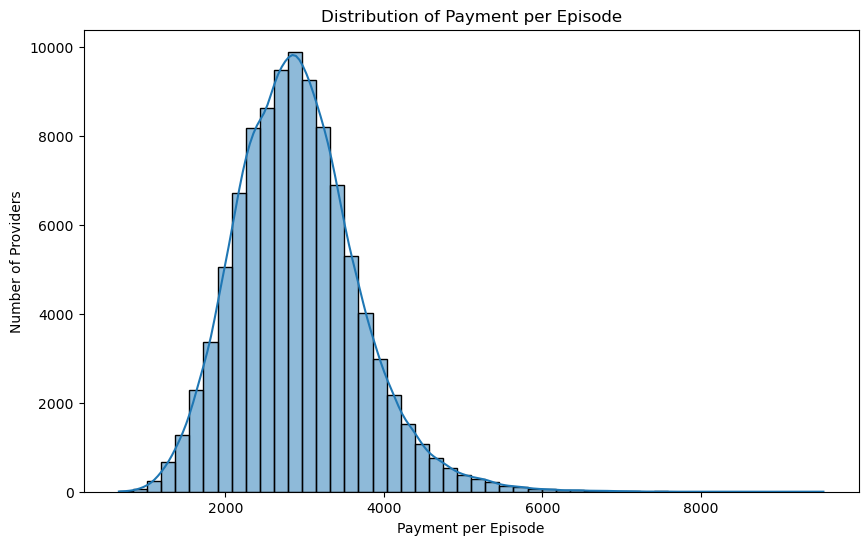

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["payment_per_episode"],
    bins=50,
    kde=True
)

plt.title("Distribution of Payment per Episode")
plt.xlabel("Payment per Episode")
plt.ylabel("Number of Providers")
plt.show()

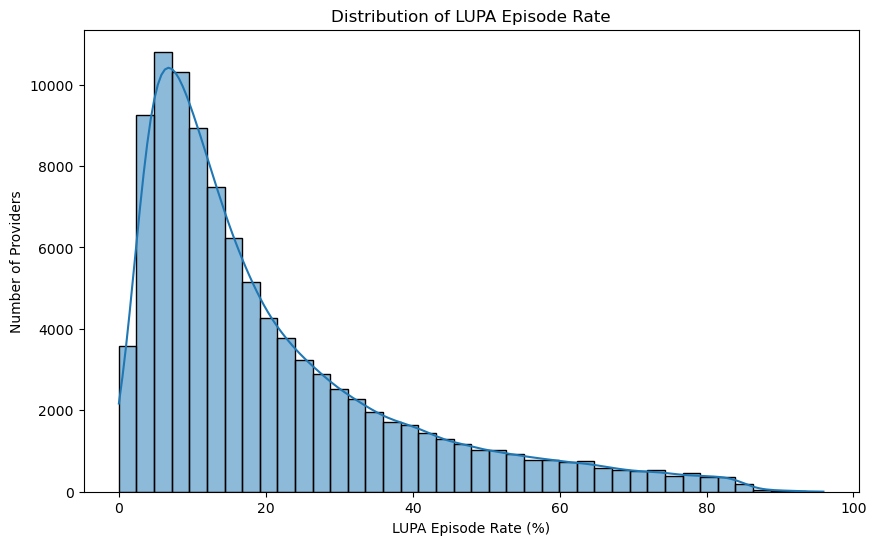

In [32]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["lupa_episode_rate"],
    bins=40,
    kde=True
)

plt.title("Distribution of LUPA Episode Rate")
plt.xlabel("LUPA Episode Rate (%)")
plt.ylabel("Number of Providers")
plt.show()

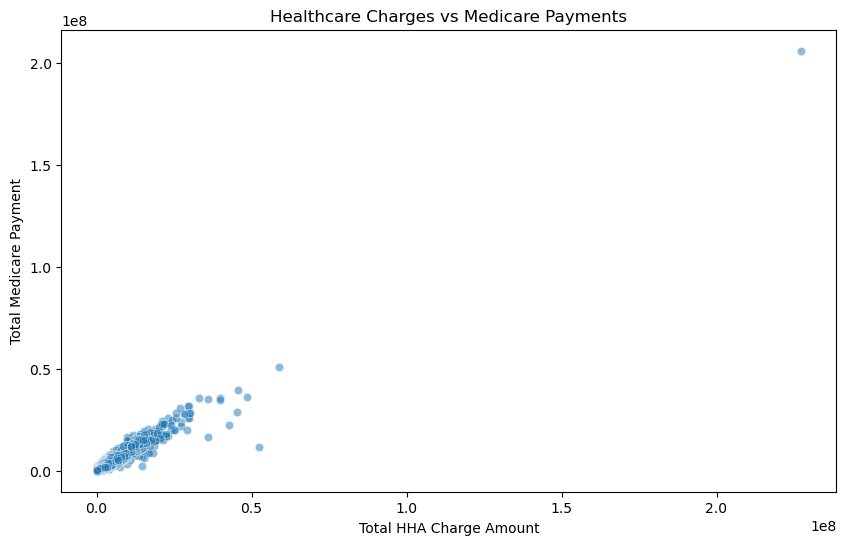

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="total_hha_charge_amount_non_lupa",
    y="total_hha_medicare_payment_amount_non_lupa",
    alpha=0.5
)

plt.title("Healthcare Charges vs Medicare Payments")
plt.xlabel("Total HHA Charge Amount")
plt.ylabel("Total Medicare Payment")
plt.show()

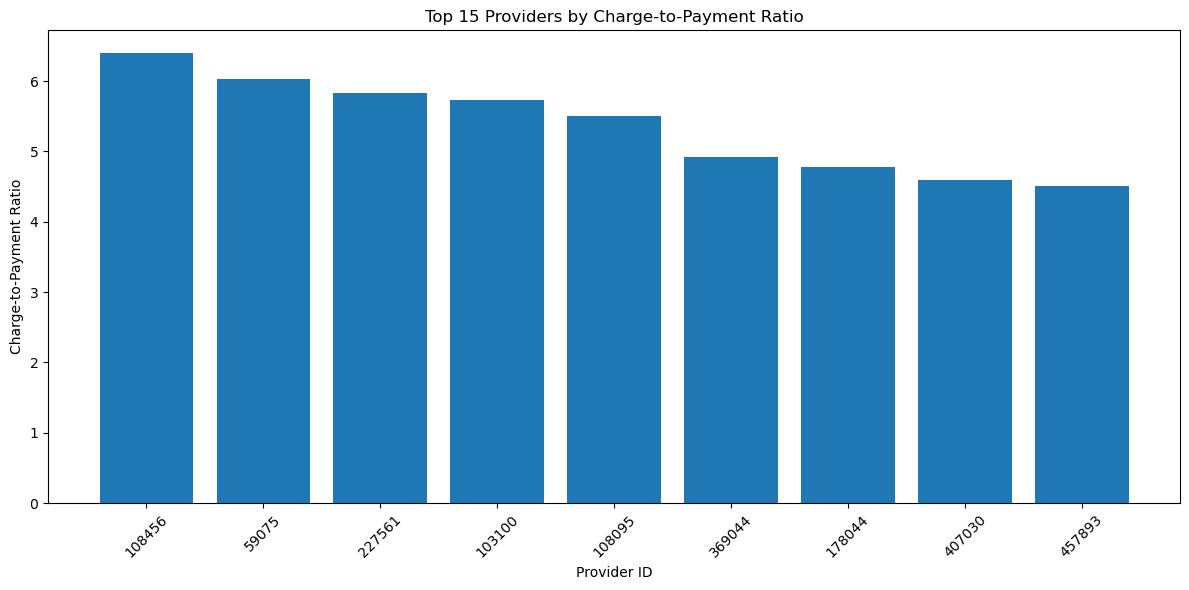

In [34]:
top_ratio = (
    df.nlargest(15, "charge_to_payment_ratio")
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_ratio["provider_id"].astype(str),
    top_ratio["charge_to_payment_ratio"]
)

plt.title("Top 15 Providers by Charge-to-Payment Ratio")
plt.xlabel("Provider ID")
plt.ylabel("Charge-to-Payment Ratio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

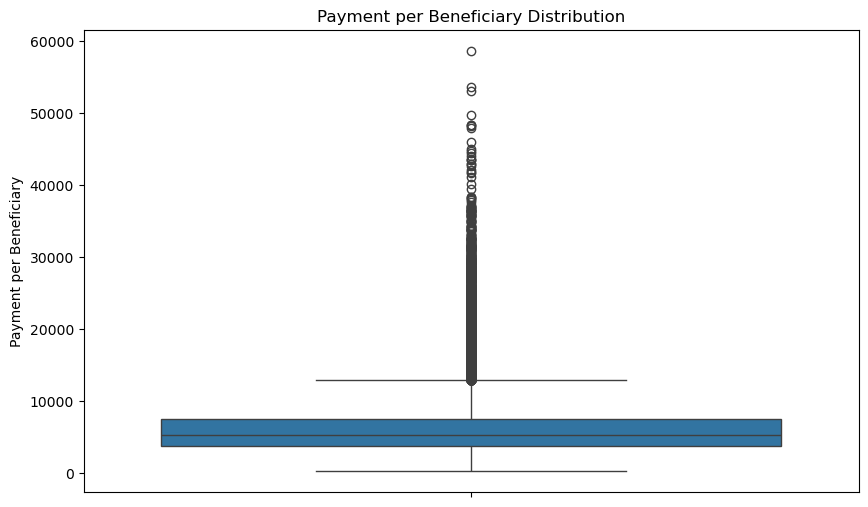

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["payment_per_beneficiary"]
)

plt.title("Payment per Beneficiary Distribution")
plt.ylabel("Payment per Beneficiary")

plt.show()

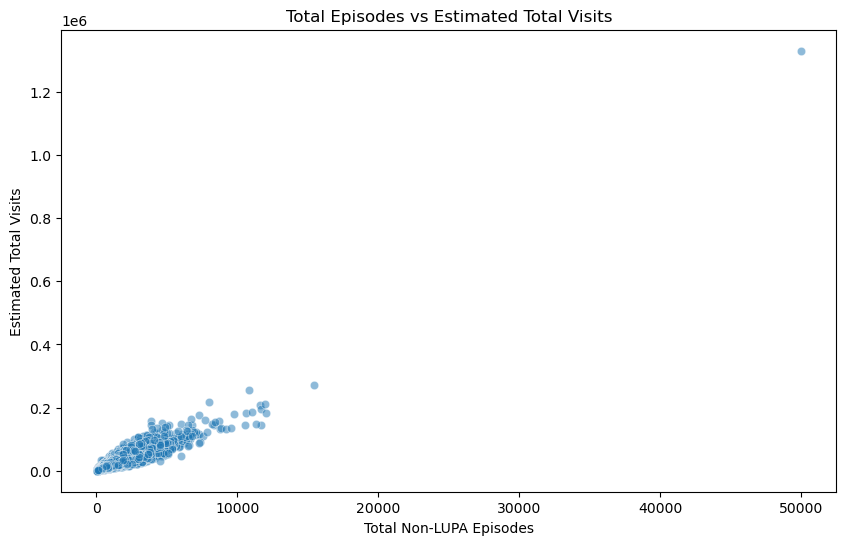

In [36]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="total_episodes_non_lupa",
    y="estimated_total_visits",
    alpha=0.5
)

plt.title("Total Episodes vs Estimated Total Visits")
plt.xlabel("Total Non-LUPA Episodes")
plt.ylabel("Estimated Total Visits")
plt.show()

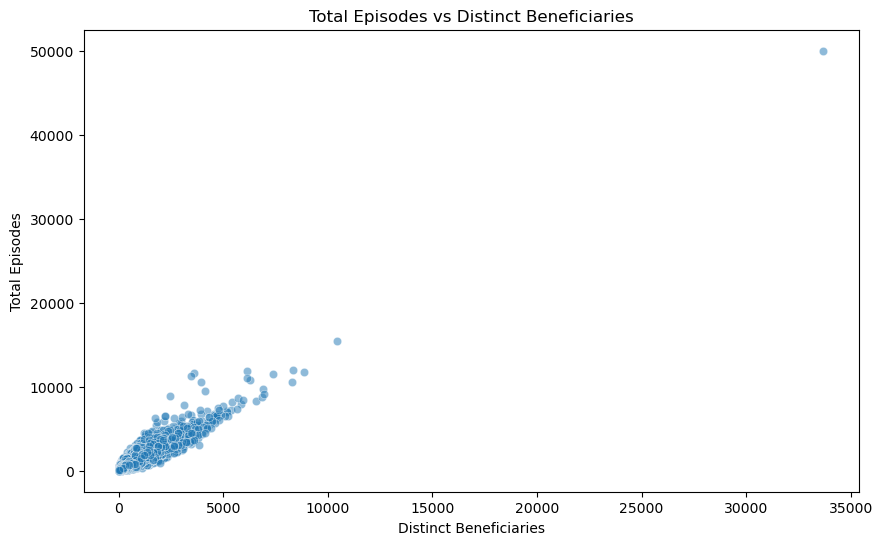

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="distinct_beneficiaries_non_lupa",
    y="total_episodes_non_lupa",
    alpha=0.5
)

plt.title("Total Episodes vs Distinct Beneficiaries")
plt.xlabel("Distinct Beneficiaries")
plt.ylabel("Total Episodes")
plt.show()